# MIT-BIH Arrhythmia Database: Dataset Exploration

**Purpose.** Explore the source records, header metadata, reference annotations, and class counts before any preprocessing or model development. The original PhysioNet files in `data/raw/mitbih/` are read only. This notebook does not filter/resample signals, relabel examples, form splits, or train models.

**Source facts.** The [PhysioNet MIT-BIH Arrhythmia Database v1.0.0 page](https://physionet.org/content/mitdb/1.0.0/) describes 48 half-hour, two-channel excerpts sampled at 360 samples/second/channel, drawn from 47 subjects. Beat-symbol definitions are taken from the [MIT-BIH directory symbol table](https://physionet.org/physiobank/database/html/mitdbdir/intro.htm) and the [PhysioNet annotation-code reference](https://archive.physionet.org/physiobank/annotations.shtml).

**Counting convention.** `beat_counts` includes standard WFDB beat labels only. Rhythm changes, waveform markers, signal-quality markers, artifacts, and other annotation symbols remain in the complete annotation-symbol table and are excluded from heartbeat-class counts. The symbol meanings are descriptive labels in the source documentation, not independent clinical interpretations. The exact label set is printed and saved below.

In [1]:
from collections import Counter
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import wfdb
from IPython.display import display

REPO_ROOT = Path.cwd().resolve()
RAW_DIR = REPO_ROOT / "data" / "raw" / "mitbih"
TABLE_DIR = REPO_ROOT / "results" / "tables"
FIGURE_DIR = REPO_ROOT / "results" / "figures"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

records_file = RAW_DIR / "RECORDS"
assert records_file.exists(), f"Missing PhysioNet RECORDS file: {records_file}"
record_ids = [line.strip() for line in records_file.read_text(encoding="utf-8").splitlines() if line.strip()]
print(f"WFDB {wfdb.__version__}; records listed: {len(record_ids)}")
print(f"Raw data root: {RAW_DIR}")

WFDB 4.3.1; records listed: 48
Raw data root: C:\Users\adni\Desktop\AI_Software_Engineering_Projects\blockchain-fl-arrhythmia-checkout\data\raw\mitbih


In [2]:
# Read every local WFDB header. Header reads do not transform signal samples.
record_rows = []
for record_id in record_ids:
    header = wfdb.rdheader(str(RAW_DIR / record_id))
    record_rows.append({
        "record_id": record_id,
        "sampling_frequency_hz": float(header.fs),
        "signal_length_samples": int(header.sig_len),
        "signal_channels": int(header.n_sig),
        "channel_names": "; ".join(header.sig_name or []),
        "units": "; ".join(header.units or []),
        "record_duration_seconds": float(header.sig_len / header.fs),
        "record_duration_minutes": float(header.sig_len / header.fs / 60),
    })

record_metadata = pd.DataFrame(record_rows).sort_values("record_id").reset_index(drop=True)
record_metadata.to_csv(TABLE_DIR / "mitbih_record_metadata.csv", index=False)
print("Records:", len(record_metadata))
print("Sampling rates (Hz):", sorted(record_metadata["sampling_frequency_hz"].unique().tolist()))
print("Signal dimensions (channels x samples):", sorted({(r.signal_channels, r.signal_length_samples) for r in record_metadata.itertuples()}))
print("Duration range (minutes):", (record_metadata.record_duration_minutes.min(), record_metadata.record_duration_minutes.max()))
display(record_metadata.head(10))
channel_configurations = (record_metadata.groupby(["channel_names", "units"], dropna=False).size().reset_index(name="record_count").sort_values("record_count", ascending=False))
channel_configurations.to_csv(TABLE_DIR / "mitbih_channel_configurations.csv", index=False)
print("Channel configurations across records:")
display(channel_configurations)

Records: 48
Sampling rates (Hz): [360.0]
Signal dimensions (channels x samples): [(2, 650000)]
Duration range (minutes): (np.float64(30.092592592592595), np.float64(30.092592592592595))


,record_id,sampling_frequency_hz,signal_length_samples,signal_channels,channel_names,units,record_duration_seconds,record_duration_minutes
0,100,360.0,650000,2,MLII; V5,mV; mV,1805.555556,30.092593
1,101,360.0,650000,2,MLII; V1,mV; mV,1805.555556,30.092593
2,102,360.0,650000,2,V5; V2,mV; mV,1805.555556,30.092593
3,103,360.0,650000,2,MLII; V2,mV; mV,1805.555556,30.092593
4,104,360.0,650000,2,V5; V2,mV; mV,1805.555556,30.092593
5,105,360.0,650000,2,MLII; V1,mV; mV,1805.555556,30.092593
6,106,360.0,650000,2,MLII; V1,mV; mV,1805.555556,30.092593
7,107,360.0,650000,2,MLII; V1,mV; mV,1805.555556,30.092593
8,108,360.0,650000,2,MLII; V1,mV; mV,1805.555556,30.092593
9,109,360.0,650000,2,MLII; V1,mV; mV,1805.555556,30.092593


Channel configurations across records:


,channel_names,units,record_count
0,MLII; V1,mV; mV,40
1,MLII; V2,mV; mV,2
3,MLII; V5,mV; mV,2
5,V5; V2,mV; mV,2
2,MLII; V4,mV; mV,1
4,V5; MLII,mV; mV,1


In [3]:
# Validate the raw files against PhysioNet's included SHA-256 manifest.
import hashlib

manifest_path = RAW_DIR / "SHA256SUMS.txt"
checksum_rows = []
for line in manifest_path.read_text(encoding="utf-8").splitlines():
    expected_hash, relative_name = line.split(maxsplit=1)
    relative_name = relative_name.strip().lstrip("*")
    source_file = RAW_DIR / relative_name
    digest = hashlib.sha256()
    with source_file.open("rb") as f:
        for block in iter(lambda: f.read(1024 * 1024), b""):
            digest.update(block)
    matches = digest.hexdigest() == expected_hash
    checksum_rows.append({"file": relative_name, "sha256_matches_physionet_manifest": matches})

checksum_table = pd.DataFrame(checksum_rows)
assert checksum_table["sha256_matches_physionet_manifest"].all(), "One or more raw files differ from the supplied PhysioNet checksums"
print(f"Verified {len(checksum_table)} source files against PhysioNet SHA-256SUMS.txt")


Verified 704 source files against PhysioNet SHA-256SUMS.txt


In [4]:
# These are standard WFDB beat-label codes. All other symbols are retained as
# non-beat annotations in the full-symbol inventory rather than forced into a class.
BEAT_SYMBOLS = {
    "N", "L", "R", "B", "A", "a", "J", "S", "V", "r", "F",
    "e", "j", "n", "E", "/", "f", "Q", "?",
}

SYMBOL_DESCRIPTIONS = {
    "N": "Normal beat",
    "L": "Left bundle branch block beat",
    "R": "Right bundle branch block beat",
    "B": "Bundle branch block beat (unspecified)",
    "A": "Atrial premature beat",
    "a": "Aberrated atrial premature beat",
    "J": "Nodal (junctional) premature beat",
    "S": "Supraventricular premature or ectopic beat (atrial or nodal)",
    "V": "Premature ventricular contraction",
    "r": "R-on-T premature ventricular contraction",
    "F": "Fusion of ventricular and normal beat",
    "e": "Atrial escape beat",
    "j": "Nodal (junctional) escape beat",
    "n": "Supraventricular escape beat (atrial or nodal)",
    "E": "Ventricular escape beat",
    "/": "Paced beat",
    "f": "Fusion of paced and normal beat",
    "Q": "Unclassifiable beat",
    "?": "Beat not classified during learning",
    "!": "Ventricular flutter wave",
    "[": "Start of ventricular flutter/fibrillation",
    "]": "End of ventricular flutter/fibrillation",
    "x": "Non-conducted P-wave (blocked atrial premature beat)",
    "|": "Isolated QRS-like artifact",
    "+": "Rhythm change marker; rhythm label is carried in the auxiliary note",
    "~": "Signal-quality change marker",
    '"': "Comment annotation",
    "(": "Waveform onset marker",
    ")": "Waveform end marker",
    "p": "P-wave peak",
    "t": "T-wave peak",
    "u": "U-wave peak",
    "^": "Pacemaker artifact",
    "s": "ST-segment change",
    "T": "T-wave change",
    "*": "Systole",
    "D": "Diastole",
    "@": "Link to external data",
}

all_symbol_counts = Counter()
beat_symbol_counts = Counter()
other_symbol_counts = Counter()
aux_note_counts = Counter()
record_annotation_counts = []
for record_id in record_ids:
    ann = wfdb.rdann(str(RAW_DIR / record_id), "atr")
    per_record = Counter(ann.symbol)
    all_symbol_counts.update(per_record)
    beat_symbol_counts.update({symbol: count for symbol, count in per_record.items() if symbol in BEAT_SYMBOLS})
    other_symbol_counts.update({symbol: count for symbol, count in per_record.items() if symbol not in BEAT_SYMBOLS})
    normalized_notes = [note.rstrip("\x00") for note in (ann.aux_note or [])]
    aux_note_counts.update(note for note in normalized_notes if note)
    record_annotation_counts.append({"record_id": record_id, "all_annotation_count": len(ann.sample), "beat_annotation_count": sum(count for symbol, count in per_record.items() if symbol in BEAT_SYMBOLS), "other_annotation_count": sum(count for symbol, count in per_record.items() if symbol not in BEAT_SYMBOLS)})

print("All annotation instances:", sum(all_symbol_counts.values()))
print("Beat annotation instances:", sum(beat_symbol_counts.values()))
print("Non-beat annotation instances:", sum(other_symbol_counts.values()))
print("Observed annotation symbols:", sorted(all_symbol_counts))
print("Observed rhythm auxiliary notes:", sorted(aux_note_counts))

All annotation instances: 112647
Beat annotation instances: 109494
Non-beat annotation instances: 3153
Observed annotation symbols: ['!', '"', '+', '/', 'A', 'E', 'F', 'J', 'L', 'N', 'Q', 'R', 'S', 'V', '[', ']', 'a', 'e', 'f', 'j', 'x', '|', '~']
Observed rhythm auxiliary notes: ['(AB', '(AFIB', '(AFL', '(B', '(BII', '(IVR', '(N', '(NOD', '(P', '(PREX', '(SBR', '(SVTA', '(T', '(VFL', '(VT', 'MISSB', 'PSE', 'TS']


In [5]:
# Complete symbol inventory, keeping non-beat annotation events visible.
all_symbol_table = pd.DataFrame([
    {
        "symbol": symbol,
        "source_description": SYMBOL_DESCRIPTIONS.get(symbol, "See PhysioNet annotation-code reference"),
        "annotation_group": "beat" if symbol in BEAT_SYMBOLS else "non-beat/event",
        "count": count,
    }
    for symbol, count in sorted(all_symbol_counts.items(), key=lambda item: (-item[1], item[0]))
])
all_symbol_table["share_of_all_annotations_pct"] = 100 * all_symbol_table["count"] / all_symbol_table["count"].sum()
all_symbol_table.to_csv(TABLE_DIR / "mitbih_all_annotation_symbol_counts.csv", index=False)

display(all_symbol_table)
print("Auxiliary-note counts (rhythm labels and any comments carried with annotations):")
aux_note_table = pd.DataFrame(aux_note_counts.most_common(), columns=["auxiliary_note", "count"])
aux_note_table.to_csv(TABLE_DIR / "mitbih_aux_note_counts.csv", index=False)
display(aux_note_table)
rhythm_note_table = aux_note_table[aux_note_table["auxiliary_note"].str.startswith("(")].copy()
print("Observed rhythm labels carried in auxiliary notes:")
display(rhythm_note_table)

,symbol,source_description,annotation_group,count,share_of_all_annotations_pct
0,N,Normal beat,beat,75052,66.625831
1,L,Left bundle branch block beat,beat,8075,7.168411
2,R,Right bundle branch block beat,beat,7259,6.444024
3,V,Premature ventricular contraction,beat,7130,6.329507
4,/,Paced beat,beat,7028,6.238959
5,A,Atrial premature beat,beat,2546,2.260158
6,+,Rhythm change marker; rhythm label is carried ...,non-beat/event,1291,1.146058
7,f,Fusion of paced and normal beat,beat,982,0.871750
8,F,Fusion of ventricular and normal beat,beat,803,0.712846
9,~,Signal-quality change marker,non-beat/event,616,0.546841


Auxiliary-note counts (rhythm labels and any comments carried with annotations):


,auxiliary_note,count
0,(N,530
1,MISSB,428
2,(B,221
3,(AFIB,107
4,(PREX,103
5,(T,83
6,(VT,61
7,(P,60
8,(AFL,45
9,(NOD,36


Observed rhythm labels carried in auxiliary notes:


,auxiliary_note,count
0,(N,530
2,(B,221
3,(AFIB,107
4,(PREX,103
5,(T,83
6,(VT,61
7,(P,60
8,(AFL,45
9,(NOD,36
10,(SVTA,26


In [6]:
# Raw beat-symbol distribution (no AAMI remapping and no record exclusions).
beat_distribution = pd.DataFrame([
    {
        "symbol": symbol,
        "source_description": SYMBOL_DESCRIPTIONS.get(symbol, "See PhysioNet annotation-code reference"),
        "count": count,
    }
    for symbol, count in beat_symbol_counts.most_common()
])
beat_distribution["share_of_beat_annotations_pct"] = 100 * beat_distribution["count"] / beat_distribution["count"].sum()
beat_distribution.to_csv(TABLE_DIR / "mitbih_beat_annotation_distribution.csv", index=False)

record_annotation_table = pd.DataFrame(record_annotation_counts).sort_values("record_id").reset_index(drop=True)
record_annotation_table.to_csv(TABLE_DIR / "mitbih_record_annotation_counts.csv", index=False)

total_beats = int(beat_distribution["count"].sum())
if len(beat_distribution):
    majority = beat_distribution.iloc[0]
    minority = beat_distribution.loc[beat_distribution["count"] > 0].sort_values("count").iloc[0]
    imbalance_ratio = float(majority["count"] / minority["count"])
    top_three_share = float(beat_distribution.head(3)["count"].sum() / total_beats * 100)
    print(f"Beat annotations counted: {total_beats:,}")
    print(f"Most frequent observed beat symbol: {majority['symbol']} ({int(majority['count']):,}; {majority['share_of_beat_annotations_pct']:.3f}%)")
    print(f"Least frequent observed beat symbol: {minority['symbol']} ({int(minority['count']):,}; {minority['share_of_beat_annotations_pct']:.3f}%)")
    print(f"Largest/smallest observed symbol count ratio: {imbalance_ratio:,.1f}:1")
    print(f"Share of top three beat symbols: {top_three_share:.3f}%")
display(beat_distribution)
display(record_annotation_table.describe(include="all"))

Beat annotations counted: 109,494
Most frequent observed beat symbol: N (75,052; 68.544%)
Least frequent observed beat symbol: S (2; 0.002%)
Largest/smallest observed symbol count ratio: 37,526.0:1
Share of top three beat symbols: 82.549%


,symbol,source_description,count,share_of_beat_annotations_pct
0,N,Normal beat,75052,68.544395
1,L,Left bundle branch block beat,8075,7.374833
2,R,Right bundle branch block beat,7259,6.629587
3,V,Premature ventricular contraction,7130,6.511772
4,/,Paced beat,7028,6.418617
5,A,Atrial premature beat,2546,2.325242
6,f,Fusion of paced and normal beat,982,0.896853
7,F,Fusion of ventricular and normal beat,803,0.733374
8,j,Nodal (junctional) escape beat,229,0.209144
9,a,Aberrated atrial premature beat,150,0.136994


,record_id,all_annotation_count,beat_annotation_count,other_annotation_count
count,48,48.000000,48.000000,48.000000
unique,48,NaN,NaN,NaN
top,100,NaN,NaN,NaN
freq,1,NaN,NaN,NaN
mean,NaN,2346.812500,2281.125000,65.687500
std,NaN,451.689107,451.956768,102.499643
min,NaN,1519.000000,1518.000000,1.000000
25%,NaN,2061.500000,1960.500000,9.000000
50%,NaN,2299.000000,2218.500000,35.000000
75%,NaN,2650.250000,2579.250000,77.500000


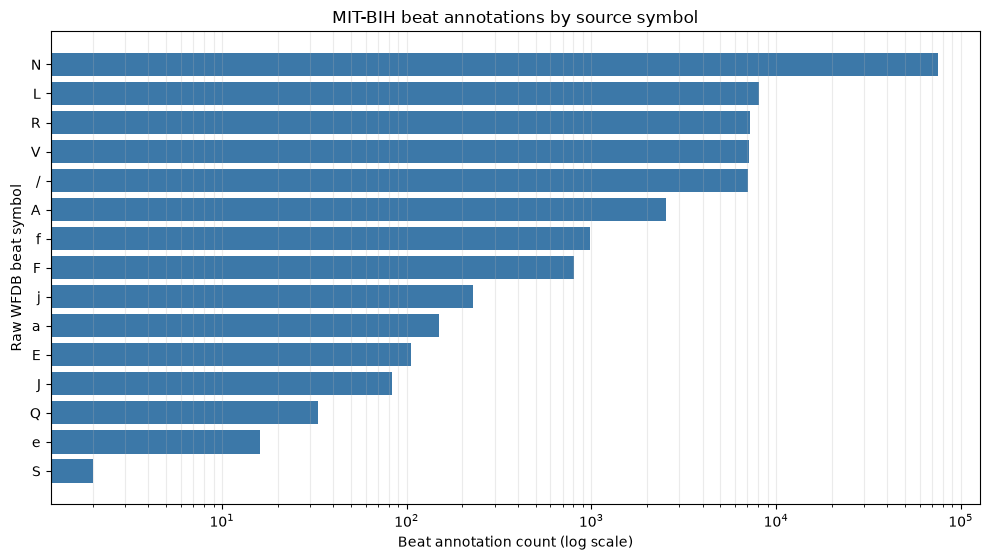

In [7]:
# Plot the annotation distribution on a logarithmic count scale so rare classes remain visible.
fig, ax = plt.subplots(figsize=(10, max(5, 0.38 * len(beat_distribution))))
plot_data = beat_distribution.sort_values("count", ascending=True)
ax.barh(plot_data["symbol"].astype(str), plot_data["count"], color="#3c78a8")
ax.set_xscale("log")
ax.set_xlabel("Beat annotation count (log scale)")
ax.set_ylabel("Raw WFDB beat symbol")
ax.set_title("MIT-BIH beat annotations by source symbol")
ax.grid(axis="x", which="both", alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "mitbih_beat_annotation_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

In [8]:
# Load representative local records for a short, unfiltered display window.
# Records 100 and 200 are selected only as examples; this is not a sampling protocol.
REPRESENTATIVE_RECORDS = ["100", "200"]
WINDOW_SECONDS = 10
representative = {}
for record_id in REPRESENTATIVE_RECORDS:
    header = wfdb.rdheader(str(RAW_DIR / record_id))
    stop = min(int(WINDOW_SECONDS * header.fs), int(header.sig_len))
    signal_record = wfdb.rdrecord(str(RAW_DIR / record_id), sampfrom=0, sampto=stop, physical=True)
    ann = wfdb.rdann(str(RAW_DIR / record_id), "atr")
    mask = ann.sample < stop
    representative[record_id] = {
        "record": signal_record,
        "samples": ann.sample[mask],
        "symbols": np.asarray(ann.symbol, dtype=object)[mask],
        "fs": float(header.fs),
        "channel_names": header.sig_name,
    }
    print(record_id, signal_record.p_signal.shape, "channels:", header.sig_name, "annotations in display window:", int(mask.sum()))

100 (3600, 2) channels: ['MLII', 'V5'] annotations in display window: 14
200 (3600, 2) channels: ['MLII', 'V1'] annotations in display window: 16


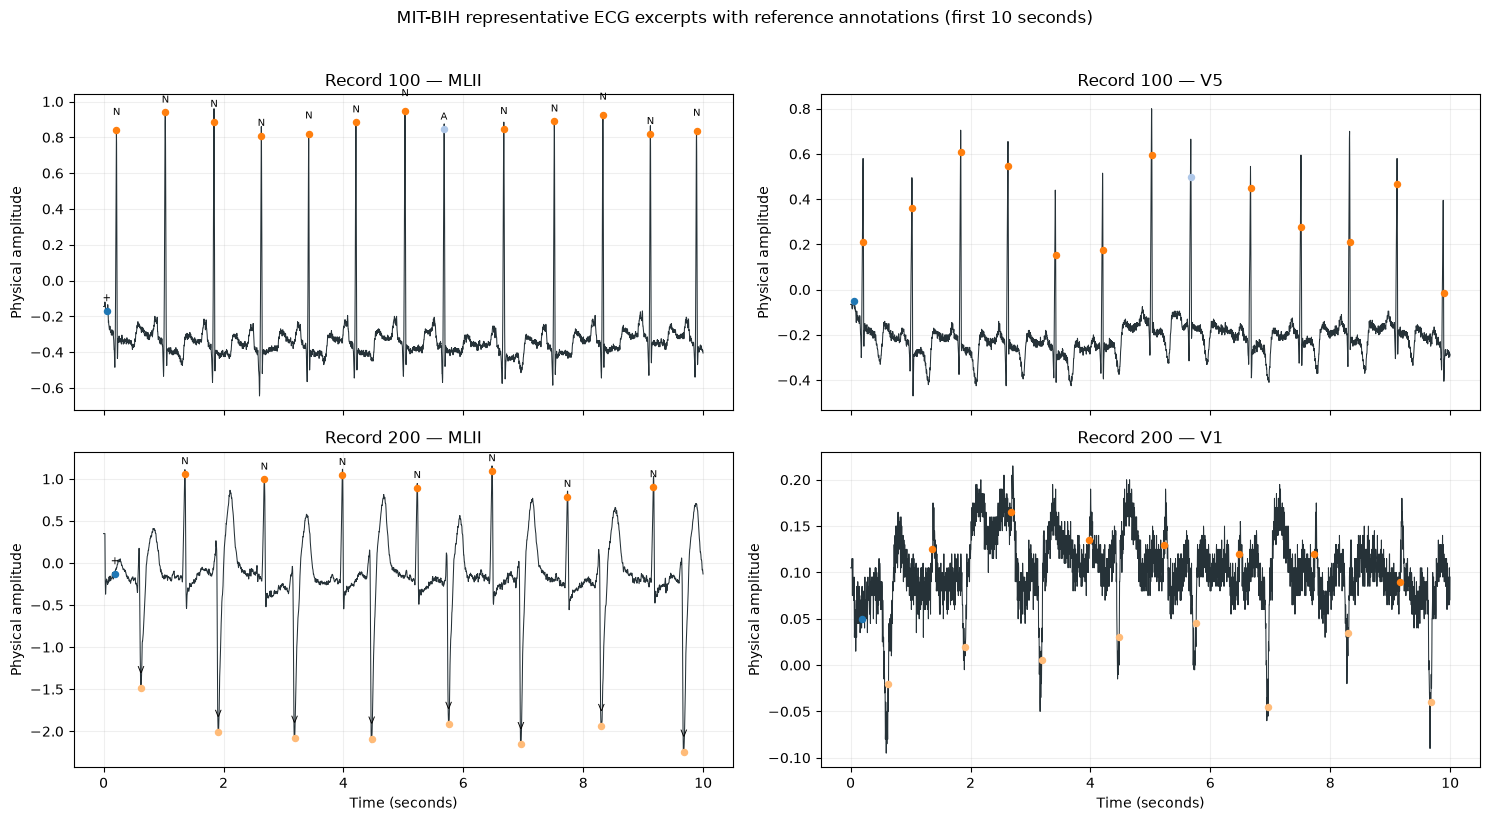

In [9]:
# Plot both signal channels for the first 10 seconds with source-symbol markers.
fig, axes = plt.subplots(len(REPRESENTATIVE_RECORDS), 2, figsize=(15, 8), sharex="col")
color_map = plt.get_cmap("tab20")
unique_symbols = sorted({str(symbol) for item in representative.values() for symbol in item["symbols"]})
symbol_colors = {symbol: color_map(index % 20) for index, symbol in enumerate(unique_symbols)}
for row, record_id in enumerate(REPRESENTATIVE_RECORDS):
    item = representative[record_id]
    signal = item["record"]
    times = np.arange(signal.p_signal.shape[0]) / item["fs"]
    for channel_index, ax in enumerate(axes[row]):
        ax.plot(times, signal.p_signal[:, channel_index], color="#263238", linewidth=0.75)
        for idx, (sample, symbol) in enumerate(zip(item["samples"], item["symbols"])):
            if sample >= len(times):
                continue
            y = signal.p_signal[int(sample), channel_index]
            color = symbol_colors[str(symbol)]
            ax.scatter(times[int(sample)], y, s=19, color=color, zorder=3)
            if channel_index == 0:
                ax.annotate(str(symbol), (times[int(sample)], y), xytext=(0, 7 + 4 * (idx % 2)), textcoords="offset points", fontsize=7, ha="center")
        channel = item["channel_names"][channel_index] if item["channel_names"] else f"channel {channel_index}"
        ax.set_title(f"Record {record_id} — {channel}")
        ax.set_ylabel("Physical amplitude")
        ax.grid(alpha=0.2)
        if row == len(REPRESENTATIVE_RECORDS) - 1:
            ax.set_xlabel("Time (seconds)")
fig.suptitle("MIT-BIH representative ECG excerpts with reference annotations (first 10 seconds)", y=1.02)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "mitbih_representative_annotations.png", dpi=180, bbox_inches="tight")
plt.show()

## Interpretation boundaries and assumptions

- Header metadata are read from the distributed `.hea` files; signal data are loaded from `.dat` through WFDB for the short example excerpts.
- The complete reference annotation files (`.atr`) are counted record by record. No event is dropped from the all-symbol inventory.
- The beat distribution uses the standard WFDB beat-symbol set shown above, without mapping symbols into a different benchmark convention such as AAMI classes. If a specific class mapping is needed for later experiments, it must be justified and documented before preprocessing.
- `aux_note` values accompany annotation events; rhythm strings such as `(AFIB` are not heartbeat class labels. They are summarized separately.
- The two plots are illustrative displays, not clinical interpretation. Channel scaling, filtering, baseline correction, beat-window extraction, subject-aware evaluation design, and class remapping remain undecided.
- Output tables and figures are derived summaries in `results/`; the source files in `data/raw/mitbih/` are not written by this notebook.